# Assembling and ranking data for the DE Africa drought monitoring

* **Products used:** 

## Background
Ranking of drought monitoring variables prior to principal component analysis as per Guillory et al. 2023.

## Description
Loading and ranking data for drought monitoring.

1. Load and rank standardised precipitation index (SPI) using CHIRPS.
2. Load and rank soil moisture.
3. Load and rank monthly NDVI.
4. Load and rank reference ET.

***

## Getting started

Provide any particular instructions that the user might need, e.g. To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` package.

In [83]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as stats

from wapordl import wapor_map
from tqdm.auto import tqdm
from deafrica_tools.load_wapor import load_wapor_ds
from deafrica_tools.spatial import xr_rasterize
from scipy.stats import gamma, norm
from odc.geo import Geometry, CRS
from odc.geo.xr import xr_reproject
from scipy import stats

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='DroughtData')

INFO: setup plugin alembic.autogenerate.schemas
INFO: setup plugin alembic.autogenerate.tables
INFO: setup plugin alembic.autogenerate.types
INFO: setup plugin alembic.autogenerate.constraints
INFO: setup plugin alembic.autogenerate.defaults
INFO: setup plugin alembic.autogenerate.comments


### Analysis parameters

We will focus on a part of Zambia for this demonstration. We've loaded the Zambia .gpkg from [GADM](https://gadm.org/index.html) into our `../data` directory.


In [3]:
zmb = gpd.read_file('data/Zambia/gadm41_ZMB.gpkg', layer = 'ADM_ADM_0')

zmb

,GID_0,COUNTRY,geometry
0,ZMB,Zambia,"MULTIPOLYGON (((25.87834 -17.97218, 25.87034 -..."


In [4]:
geom = Geometry(geom=zmb.geometry.union_all(), crs=zmb.crs)

## Load CHIRPS Monthly Rainfall Data

Load monthly rainfall.

In [5]:
time_m = ('2018', '2025')

# CHIRPS has a spatial resolution of ~5x5 km = 0.05 deg x 0.05 deg
resolution = (-0.2, 0.2)

# size of dask chunks - NOT using at low resolution
# dask_chunks = dict(longitude=500,latitude=500, time = -1)

query = {'geopolygon': geom,
         'time': time_m,
         'output_crs': 'epsg:4326',
         'resolution': resolution,
         'measurements': ['rainfall']
        }

ds_rf = dc.load(product='rainfall_chirps_monthly', **query)

ds_rf['time'] = ds_rf['time'].values.astype('datetime64[M]')

ds_rf

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 92, latitude: 50, longitude: 60)
Coordinates:
  * time         (time) datetime64[s] 736B 2018-01-01 2018-02-01 ... 2025-12-01
  * latitude     (latitude) float64 400B -8.3 -8.5 -8.7 ... -17.7 -17.9 -18.1
  * longitude    (longitude) float64 480B 21.9 22.1 22.3 22.5 ... 33.3 33.5 33.7
    spatial_ref  int32 4B 4326
Data variables:
    rainfall     (time, latitude, longitude) float32 1MB 141.4 142.5 ... 389.1
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

### Calculate Standardised Precipitation Index

In [6]:
# 1. 3-Month Accumulated Rainfall
rainfall_3m = ds_rf["rainfall"].rolling(time=3, min_periods=3).sum()

# Robust SciPy SPI-1D fitting function
def _scipy_spi_1d(arr):
  if np.isnan(arr).all():
    return arr

  nan_mask = np.isnan(arr)
  valid_p = arr[~nan_mask]

  if len(valid_p) < 3:
    return np.full_like(arr, np.nan)

  # Treat all values <= 0 as zero rainfall (handles floating-point precision like -1e-12)
  zeros_mask = valid_p <= 0
  q = np.sum(zeros_mask) / len(valid_p)
  non_zeros = valid_p[~zeros_mask]

  spi_valid = np.full_like(valid_p, np.nan)

  # Must have strictly positive values AND non-zero variance to fit Gamma
  if len(non_zeros) >= 3 and np.std(non_zeros) > 0:
    try:
      # Fit Gamma distribution (floc=0 fixes location parameter to 0)
      shape, loc, scale = gamma.fit(non_zeros, floc=0)
      g_x = gamma.cdf(non_zeros, shape, loc=loc, scale=scale)

      # Cumulative probability H(x) = q + (1 - q) * G(x)
      h_x = np.clip(q + (1 - q) * g_x, 1e-6, 1 - 1e-6)

      # Standard Normal Transformation
      spi_valid[~zeros_mask] = norm.ppf(h_x)

      if np.any(zeros_mask):
        spi_valid[zeros_mask] = norm.ppf(np.clip(q, 1e-6, 1 - 1e-6))
    except Exception:
      # Fallback to NaN if numerical optimization fails to converge
      pass
  elif len(non_zeros) == 0:
    # If every value in the time series is 0
    spi_valid[:] = norm.ppf(np.clip(q, 1e-6, 1 - 1e-6))

  spi_full = np.full_like(arr, np.nan)
  spi_full[~nan_mask] = spi_valid
  return spi_full


# Apply vectorized across time dimension per month group
spi_3_da = (
    rainfall_3m.groupby("time.month")
    .map(
        lambda da: xr.apply_ufunc(
            _scipy_spi_1d,
            da,
            input_core_dims=[["time"]],
            output_core_dims=[["time"]],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float],
        )
    )
    .sortby("time")
)

# Save directly into fresh Dataset
ds_spi3 = xr.Dataset(data_vars={"SPI_3": spi_3_da}, coords=ds_rf.coords)

ds_spi3

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 92, latitude: 50, longitude: 60)
Coordinates:
  * time         (time) datetime64[s] 736B 2018-01-01 2018-02-01 ... 2025-12-01
  * latitude     (latitude) float64 400B -8.3 -8.5 -8.7 ... -17.7 -17.9 -18.1
  * longitude    (longitude) float64 480B 21.9 22.1 22.3 22.5 ... 33.3 33.5 33.7
    spatial_ref  int32 4B 4326
Data variables:
    SPI_3        (time, latitude, longitude) float64 2MB nan nan ... 1.698 1.659

## Repeat for soil moisture
Get the data for soil moisture and percentile rank it.

In [7]:
opendap_url = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpcsoil/soilw.mon.mean.v2.nc"

# Open the dataset lazily (this takes less than a second)
# chunks={} tells xarray to optimize data streaming via Dask if available
ds = xr.open_dataset(opendap_url, chunks={})

In [22]:
zmb_sm = ds['soilw'].sel(
    time=slice("2018-01-01", "2025-12-31"),
    lat=slice(zmb.total_bounds[3], zmb.total_bounds[1]),  # Slicing from North to South depending on grid orientation
    lon=slice(zmb.total_bounds[0], zmb.total_bounds[2])
).load()

# assign the CRS to the soil moisture DataArray
zmb_sm = zmb_sm.rio.write_crs("EPSG:4326")

# ensure coordinate dimension names are recognized as spatial (x/y)
zmb_sm = zmb_sm.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

zmb_sm = zmb_sm.rename({'lat':'y', 'lon':'x'})

zmb_sm['time'] = zmb_sm['time'].values.astype('datetime64[M]')

zmb_sm

<xarray.DataArray 'soilw' (time: 96, y: 19, x: 23)> Size: 168kB
array([[[379.8842  , 305.9991  , 282.35754 , ..., 571.6351  ,
         421.82773 , 413.2018  ],
        [375.3599  , 326.44168 , 316.57654 , ..., 524.312   ,
         496.74094 , 509.40863 ],
        [359.5055  , 337.31998 , 343.7252  , ..., 511.65683 ,
         519.22644 , 546.9415  ],
        ...,
        [236.85107 , 249.76819 , 249.10875 , ..., 194.84177 ,
         187.00024 , 181.397   ],
        [227.06381 , 241.12991 , 238.02365 , ..., 215.35754 ,
         213.35988 , 224.1674  ],
        [223.48083 , 233.81902 , 232.92538 , ..., 268.44516 ,
         309.39566 , 307.1904  ]],

       [[393.6883  , 314.22586 , 294.62637 , ..., 603.86206 ,
         480.69284 , 479.06528 ],
        [388.89392 , 339.74158 , 331.52817 , ..., 576.1205  ,
         561.67365 , 577.0793  ],
        [387.12735 , 359.3753  , 357.86813 , ..., 571.8796  ,
         583.67316 , 610.7095  ],
...
        [161.867   , 162.36469 , 158.6144  , ..., 139.1886  ,
         142.23346 , 136.39133 ],
        [154.3524  , 158.1696  , 167.05823 , ..., 174.19414 ,
         161.7712  , 158.44754 ],
        [164.31447 , 165.78838 , 165.53615 , ..., 202.94836 ,
         221.77092 , 206.84476 ]],

       [[277.1293  , 279.8639  , 248.0724  , ..., 362.2173  ,
         305.18903 , 301.3291  ],
        [243.00865 , 236.55006 , 247.82951 , ..., 346.1945  ,
         325.2665  , 326.3749  ],
        [225.24986 , 219.54309 , 230.45729 , ..., 332.78317 ,
         330.00333 , 340.3755  ],
        ...,
        [275.15768 , 282.31094 , 281.21133 , ..., 244.60492 ,
         245.16992 , 242.92598 ],
        [268.59616 , 276.15692 , 276.5178  , ..., 272.33298 ,
         262.3371  , 264.42374 ],
        [267.65012 , 263.79285 , 251.55829 , ..., 299.6975  ,
         340.97153 , 351.08316 ]]], shape=(96, 19, 23), dtype=float32)
Coordinates:
  * time         (time) datetime64[s] 768B 2018-01-01 2018-02-01 ... 2025-12-01
  * y            (y) float32 76B -8.75 -9.25 -9.75 ... -16.75 -17.25 -17.75
  * x            (x) float32 92B 22.25 22.75 23.25 23.75 ... 32.25 32.75 33.25
    spatial_ref  int64 8B 0
Attributes:
    long_name:      Model-Calculated Monthly Mean Soil Moisture
    units:          mm
    valid_range:    [   0. 1000.]
    dataset:        CPC Monthly Soil Moisture
    var_desc:       Soil Moisture
    level_desc:     Surface
    statistic:      Monthly Mean
    parent_stat:    Other
    standard_name:  lwe_thickness_of_soil_moisture_content
    cell_methods:   time: mean (monthly from values)
    actual_range:   [  0.      759.12964]
    _ChunkSizes:    [  1 360 720]

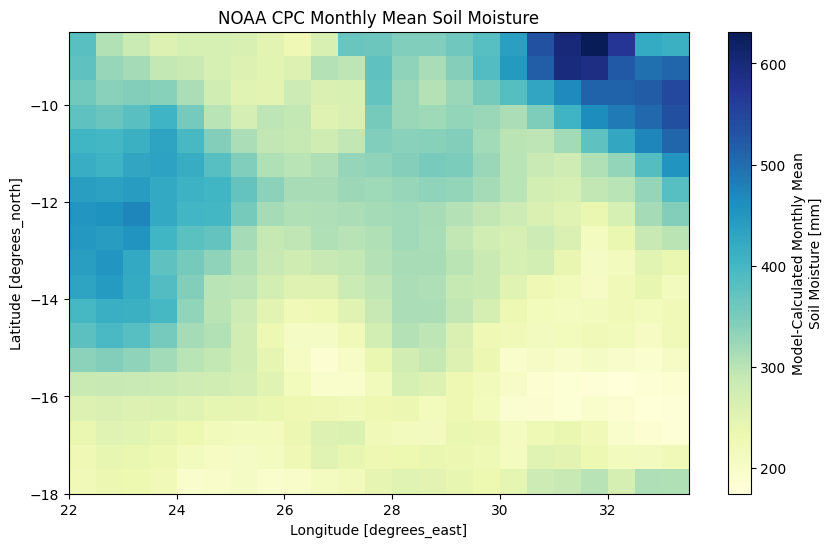

In [23]:
# 4. Trigger the actual data stream by plotting or computing
plt.figure(figsize=(10, 6))
zmb_sm.isel(time=0).plot(cmap="YlGnBu")
plt.title("NOAA CPC Monthly Mean Soil Moisture")
plt.show()

## Repeat for Reference ET
Get the data for soil moisture and percentile rank it.

### WaPOR

In [10]:
folder = "data/WaPOR" # folder that the data will be sent to
variable = "L1-RET-M" # level-variable-time, see table above
period = ["2018-01-01", "2025-12-31"] # period to load

region = [zmb.total_bounds[0], zmb.total_bounds[1], zmb.total_bounds[2], zmb.total_bounds[3]]

In [11]:
ret = wapor_map(region, variable, period, folder, extension = '.nc')

ret_xr = load_wapor_ds(filename=ret, variable=variable)

ret_xr = ret_xr.rio.write_crs("EPSG:4326")

ret_xr = ret_xr.rio.set_spatial_dims(x_dim="x", y_dim="y")

ret_xr['time'] = ret_xr['time'].values.astype('datetime64[M]')

ret_xr["L1-RET-M"] = ret_xr["L1-RET-M"].where(ret_xr["L1-RET-M"] > -999.9, np.nan)

ret_xr

INFO: Found 96 files for L1-RET-M.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset> Size: 1MB
Dimensions:      (x: 38, y: 40, time: 96)
Coordinates:
  * x            (x) float64 304B 22.03 22.34 22.66 22.97 ... 32.97 33.28 33.59
  * y            (y) float64 320B -8.375 -8.625 -8.875 ... -17.62 -17.88 -18.12
  * time         (time) datetime64[s] 768B 2018-01-01 2018-02-01 ... 2025-12-01
    spatial_ref  int64 8B 0
Data variables:
    L1-RET-M     (time, y, x) float64 1MB 113.2 113.9 111.3 ... nan nan nan
Attributes: (12/13)
    lat#long_name:        latitude
    lat#standard_name:    latitude
    lat#units:            degrees_north
    lon#long_name:        longitude
    lon#standard_name:    longitude
    lon#units:            degrees_east
    ...                   ...
    overview:             NONE
    temporal_resolution:  Month
    units:                mm/month
    scale_factor:         0.1
    _FillValue:           -9999
    add_offset:           0.0

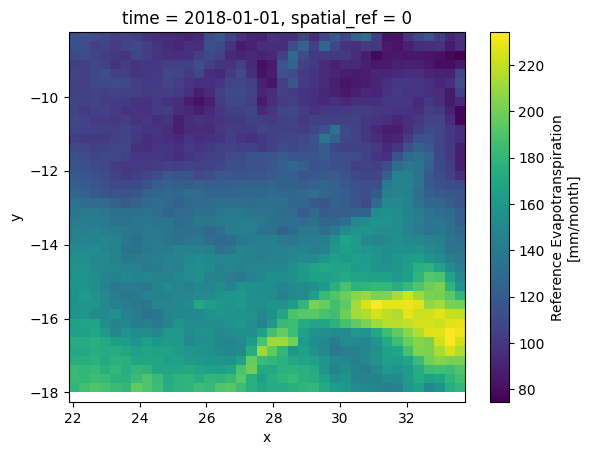

In [12]:
ret_xr[variable].isel(time=0).plot()

# Repeat for NDVI

Note that we are loading in low resolution.

In [ ]:
pbar = tqdm(total=100, desc="Loading Datacube Data")

def update_progress(current, total):
    pbar.total = total
    pbar.n = current
    pbar.refresh() 

query = {'geopolygon': geom,
         'time': time_m,
         'output_crs': 'epsg:4326',
         'resolution': resolution,
         'measurements': ['ndvi_mean'],
         'resampling': 'average'
        }

ds_ndvi = dc.load(product='ndvi_anomaly', **query, progress_cbk=update_progress)

pbar.close() 

ds_ndvi['time'] = ds_ndvi['time'].values.astype('datetime64[M]')

ds_ndvi

Loading Datacube Data:   0%|          | 0/100 [00:00<?, ?it/s]

# Merge datasets

Start by resampling soil moisture to match NDVI and rainfall.

In [24]:
sm_reprj = xr_reproject(zmb_sm, how=ds_spi3.odc.geobox, resampling='average').to_dataset(name='soil-moisture')
                                                                                               
sm_reprj

<xarray.Dataset> Size: 1MB
Dimensions:        (time: 96, latitude: 50, longitude: 60)
Coordinates:
  * time           (time) datetime64[s] 768B 2018-01-01 ... 2025-12-01
  * latitude       (latitude) float64 400B -8.3 -8.5 -8.7 ... -17.7 -17.9 -18.1
  * longitude      (longitude) float64 480B 21.9 22.1 22.3 ... 33.3 33.5 33.7
    spatial_ref    int32 4B 4326
Data variables:
    soil-moisture  (time, latitude, longitude) float32 1MB nan nan ... nan nan

Repeat for reference ET.

In [15]:
ret_reprj = xr_reproject(ret_xr, how=ds_spi3.odc.geobox, resampling='bilinear')

ret_reprj["L1-RET-M"] = ret_reprj["L1-RET-M"].where(ret_reprj["L1-RET-M"] > -999.9, np.nan)

ret_reprj

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 96, latitude: 50, longitude: 60)
Coordinates:
  * time         (time) datetime64[s] 768B 2018-01-01 2018-02-01 ... 2025-12-01
  * latitude     (latitude) float64 400B -8.3 -8.5 -8.7 ... -17.7 -17.9 -18.1
  * longitude    (longitude) float64 480B 21.9 22.1 22.3 22.5 ... 33.3 33.5 33.7
    spatial_ref  int32 4B 4326
Data variables:
    L1-RET-M     (time, latitude, longitude) float64 2MB 113.2 113.4 ... nan nan
Attributes: (12/13)
    lat#long_name:        latitude
    lat#standard_name:    latitude
    lat#units:            degrees_north
    lon#long_name:        longitude
    lon#standard_name:    longitude
    lon#units:            degrees_east
    ...                   ...
    overview:             NONE
    temporal_resolution:  Month
    units:                mm/month
    scale_factor:         0.1
    _FillValue:           -9999
    add_offset:           0.0

## Combine four variables into one dataset

In [25]:
ds_comb = xr.merge([ds_ndvi, ds_spi3, sm_reprj, ret_reprj])
ds_comb

/tmp/ipykernel_387/3739720633.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_comb = xr.merge([ds_ndvi, ds_spi3, sm_reprj, ret_reprj])
/tmp/ipykernel_387/3739720633.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_comb = xr.merge([ds_ndvi, ds_spi3, sm_reprj, ret_reprj])


<xarray.Dataset> Size: 7MB
Dimensions:        (time: 96, latitude: 50, longitude: 60)
Coordinates:
  * time           (time) datetime64[s] 768B 2018-01-01 ... 2025-12-01
  * latitude       (latitude) float64 400B -8.3 -8.5 -8.7 ... -17.7 -17.9 -18.1
  * longitude      (longitude) float64 480B 21.9 22.1 22.3 ... 33.3 33.5 33.7
    spatial_ref    int32 4B 4326
Data variables:
    ndvi_mean      (time, latitude, longitude) float32 1MB nan nan ... nan nan
    SPI_3          (time, latitude, longitude) float64 2MB nan nan ... 1.659
    soil-moisture  (time, latitude, longitude) float32 1MB nan nan ... nan nan
    L1-RET-M       (time, latitude, longitude) float64 2MB 113.2 113.4 ... nan
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

### Clip to country

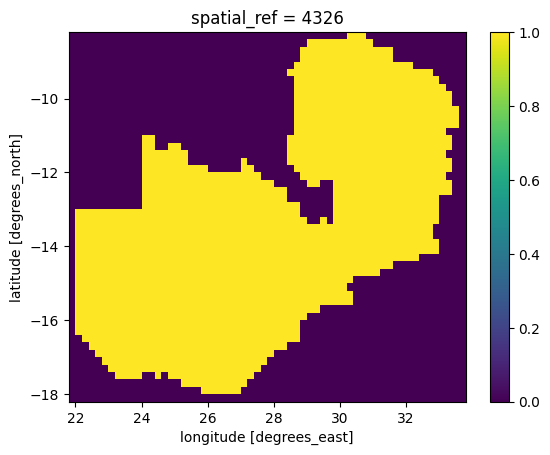

In [17]:
mask = xr_rasterize(zmb, ds_comb)

mask.plot()

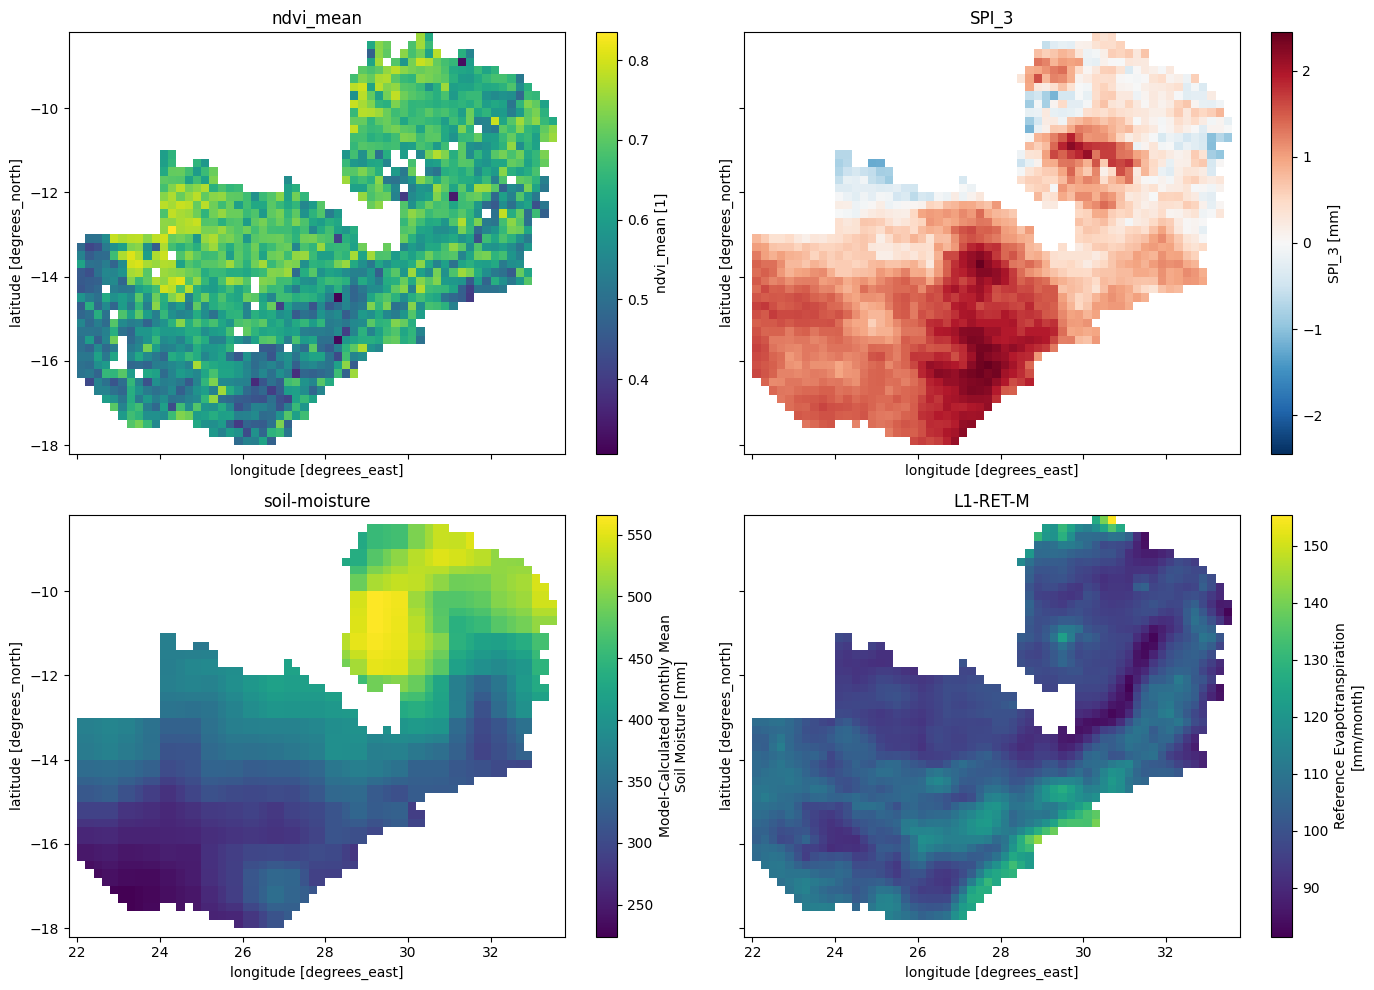

In [26]:
ds_comb = ds_comb.where(mask)

# 1. Create a 2x2 subplot layout
ds_slice = ds_comb.isel(time=4)

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()

# 3. Loop over the four data variables and plot each
for i, var_name in enumerate(ds_slice.data_vars):
    if i < 4:  # Safety boundary for 4 variables
        ds_slice[var_name].plot(ax=axes_flat[i])
        axes_flat[i].set_title(var_name)

# 4. Clean up alignment and render
plt.tight_layout()
plt.show()

# Percentile ranking

In [49]:
# compute percentiles

spi_pct = (
    ds_comb.SPI_3.groupby("time.month")
    .map(lambda x: x.rank(dim="time", pct=True))
    .sortby("time")
)
ndvi_pct = (
    ds_comb.ndvi_mean.groupby("time.month")
    .map(lambda x: x.rank(dim="time", pct=True))
    .sortby("time")
)
sm_pct = (
    ds_comb['soil-moisture'].groupby("time.month")
    .map(lambda x: x.rank(dim="time", pct=True))
    .sortby("time")
)

# inverted percentiles for Reference ET (High ET = 0.0 Drought Signal)
# 1.0 - standard_rank
ret_pct = 1.0 - (
    ds_comb['L1-RET-M'].groupby("time.month")
    .map(lambda x: x.rank(dim="time", pct=True))
    .sortby("time")
)

# Assemble into ds_percentiles
ds_percentiles = xr.Dataset(
    data_vars={
        "SPI_3": spi_pct,
        "ndvi_mean": ndvi_pct,
        "soil-moisture": sm_pct,
        "L1-RET-M": ret_pct,
    }
)

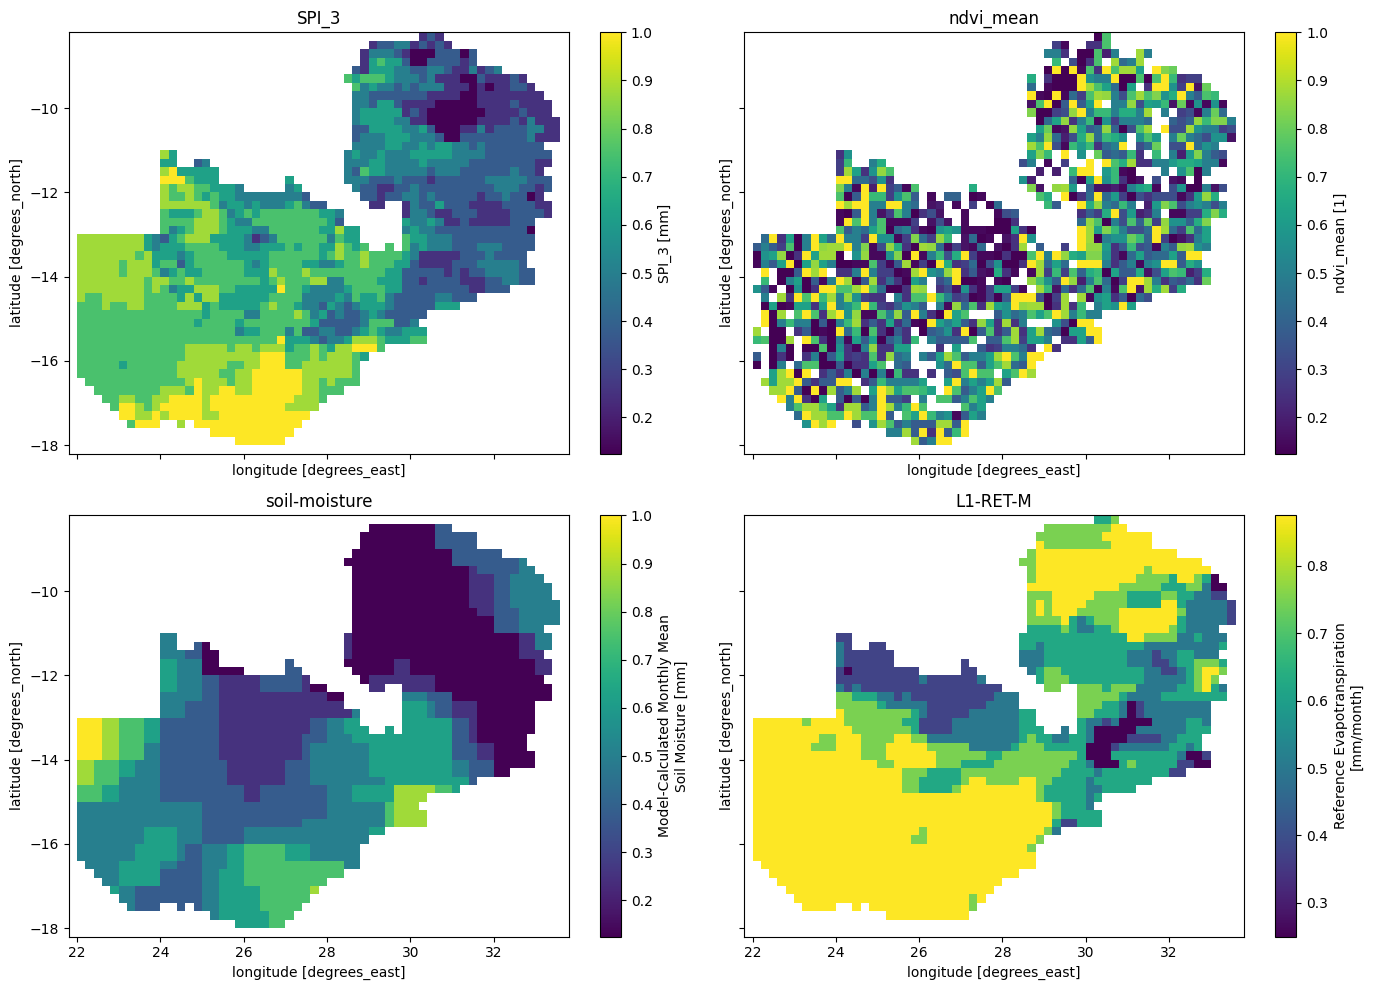

In [50]:
# 1. Create a 2x2 subplot layout
ds_pct_slice = ds_percentiles.isel(time=2)

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()

# 3. Loop over the four data variables and plot each
for i, var_name in enumerate(ds_pct_slice.data_vars):
    if i < 4:  # Safety boundary for 4 variables
        ds_pct_slice[var_name].plot(ax=axes_flat[i])
        axes_flat[i].set_title(var_name)

# 4. Clean up alignment and render
plt.tight_layout()
plt.show()

# Run percentile checks

In [51]:
# Select a single month (e.g., all Januaries) for one variable across all years
jan_raw = ds_comb['SPI_3'].sel(time=ds_comb.time.dt.month == 1)
jan_pct = ds_percentiles['SPI_3'].sel(time=ds_percentiles.time.dt.month == 1)

# Grab two specific spatial points
pixel_1_raw = jan_raw.isel(latitude=25, longitude=25)
pixel_1_pct = jan_pct.isel(latitude=25, longitude=25)

pixel_2_raw = jan_raw.isel(latitude=18, longitude=18)
pixel_2_pct = jan_pct.isel(latitude=18, longitude=18)

# The highest raw value at Pixel 1 across all Januaries MUST correspond to 1.0 (or 100%) at Pixel 1
print("Pixel 1 Max Raw Year Index:", pixel_1_raw.argmax(dim="time").values)
print("Pixel 1 Max Percentile Value:", pixel_1_pct.max(dim="time").values) # Should be 1.0

print("Pixel 2 Max Raw Year Index:", pixel_2_raw.argmax(dim="time").values)
print("Pixel 2 Max Percentile Value:", pixel_2_pct.max(dim="time").values) # Should be 1.0

Pixel 1 Max Raw Year Index: 3
Pixel 1 Max Percentile Value: 1.0
Pixel 2 Max Raw Year Index: 1
Pixel 2 Max Percentile Value: 1.0


In [52]:
# Pick a single spatial point (lat, lon) and a single month (e.g., month 5 / May)
lat_idx, lon_idx = 25, 25
month_num = 5

# Extract raw and ranked time-series for May at this point
raw_series = ds_comb['soil-moisture'].sel(time=ds_comb.time.dt.month == month_num).isel(latitude=lat_idx, longitude=lon_idx).to_pandas()
pct_series = ds_percentiles['soil-moisture'].sel(time=ds_percentiles.time.dt.month == month_num).isel(latitude=lat_idx, longitude=lon_idx).to_pandas()

# Create a validation DataFrame
df_check = pd.DataFrame({"Raw_Value": raw_series, "Percentile_Rank": pct_series})

# Sort by raw value
df_check_sorted = df_check.sort_values(by="Raw_Value")

print(f"--- Verification for Month {month_num} at Pixel ({lat_idx}, {lon_idx}) ---")
print(df_check_sorted)

# Assertion test: Is the Percentile Rank monotonically increasing when sorted by Raw_Value?
assert df_check_sorted['Percentile_Rank'].is_monotonic_increasing, "FAILED: Ranks are not properly ordered by month!"
print("\n✅ PASSED: Ranks correctly correspond to month-grouped order!")

--- Verification for Month 5 at Pixel (25, 25) ---
             Raw_Value  Percentile_Rank
time                                   
2019-05-01  313.968231            0.125
2024-05-01  339.407288            0.250
2018-05-01  374.407440            0.375
2025-05-01  381.444183            0.500
2020-05-01  406.216095            0.625
2021-05-01  408.154388            0.750
2023-05-01  446.284332            0.875
2022-05-01  505.958984            1.000

✅ PASSED: Ranks correctly correspond to month-grouped order!


In [53]:
# Check unique percentile values for a specific pixel and month
pixel_jan_ranks = ds_percentiles['ndvi_mean'].sel(time=ds_percentiles.time.dt.month == 8).isel(latitude=25, longitude=25).values

print("Unique Jan percentile ranks at selected pixel:")
print(np.sort(pixel_jan_ranks))

# For 8 total years, valid outputs should ideally be: [0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

Unique Jan percentile ranks at selected pixel:
[0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]


# Conduct Principal Component Analysis

In [54]:
# 1. Define exact variable names from your dataset
var_names = ["ndvi_mean", "SPI_3", "soil-moisture", "L1-RET-M"]

# 2. Slice baseline period if desired (e.g. up to 2020-11 per paper),
# or use full available record if restricted to 2018–2025
# ds_baseline = ds_percentiles.sel(time=slice("2018-01-01", "2020-11-30"))
ds_baseline = ds_percentiles  # Uses full dataset

# 3. Stack spatiotemporal dimensions into a 2D table (N_samples, 4 variables)
df_list = []
for var in var_names:
  # Flatten time, latitude, longitude into 1D series
  df_list.append(ds_baseline[var].values.flatten())

# Create pandas DataFrame where each column is one variable
df_data = pd.DataFrame(dict(zip(var_names, df_list))).dropna()

# 4. Compute 4x4 Correlation Matrix
corr_matrix = df_data.corr().values

# 5. Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# 6. Extract eigenvector associated with the first principal component (max eigenvalue)
first_pc_idx = np.argmax(eigenvalues)
v1 = eigenvectors[:, first_pc_idx]

# Ensure unit length normalization (||v1|| = 1)
v1 = v1 / np.linalg.norm(v1)

# 7. Derive weights by taking the squared components: w_i = v_1,i^2
weights_array = v1**2

# Standardize sum to 1.0 (guaranteed mathematically for unit eigenvectors)
weights_array = weights_array / np.sum(weights_array)

# Map weights back to variable names
weights = dict(zip(var_names, weights_array))

print("--- Calculated PCA Weights ---")
for var, w in weights.items():
  print(f"{var}: {w:.4f}")

--- Calculated PCA Weights ---
ndvi_mean: 0.1672
SPI_3: 0.2199
soil-moisture: 0.3248
L1-RET-M: 0.2880


In [55]:
# 1. Compute weighted sum across all 4 percentile variables
ds_percentiles["CDI"] = sum(
    ds_percentiles[var] * weight for var, weight in weights.items()
)

# 2. Add metadata description
ds_percentiles["CDI"].attrs["long_name"] = "Combined Drought Index (CDI)"
ds_percentiles["CDI"].attrs["weights"] = str(
    {k: round(v, 4) for k, v in weights.items()}
)

ds_percentiles

<xarray.Dataset> Size: 12MB
Dimensions:        (time: 96, latitude: 50, longitude: 60)
Coordinates:
  * time           (time) datetime64[s] 768B 2018-01-01 ... 2025-12-01
  * latitude       (latitude) float64 400B -8.3 -8.5 -8.7 ... -17.7 -17.9 -18.1
  * longitude      (longitude) float64 480B 21.9 22.1 22.3 ... 33.3 33.5 33.7
    spatial_ref    int32 4B 4326
Data variables:
    SPI_3          (time, latitude, longitude) float64 2MB nan nan ... nan nan
    ndvi_mean      (time, latitude, longitude) float64 2MB nan nan ... nan nan
    soil-moisture  (time, latitude, longitude) float64 2MB nan nan ... nan nan
    L1-RET-M       (time, latitude, longitude) float64 2MB nan nan ... nan nan
    CDI            (time, latitude, longitude) float64 2MB nan nan ... nan nan

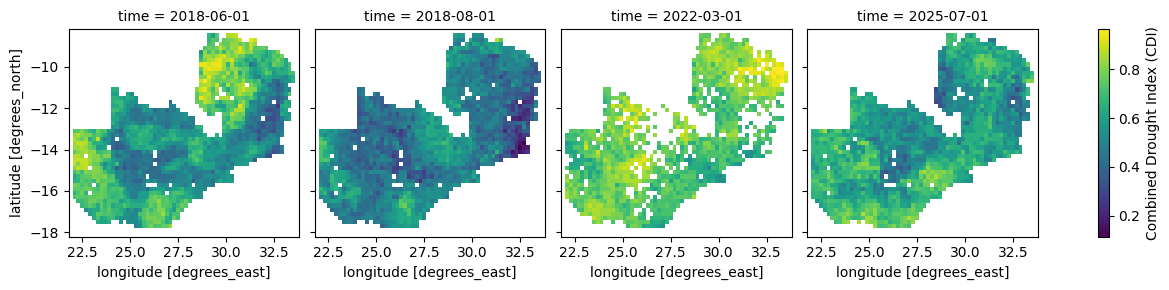

In [60]:
ds_percentiles.isel(time=[5, 7, 50, 90]).CDI.plot(col='time')

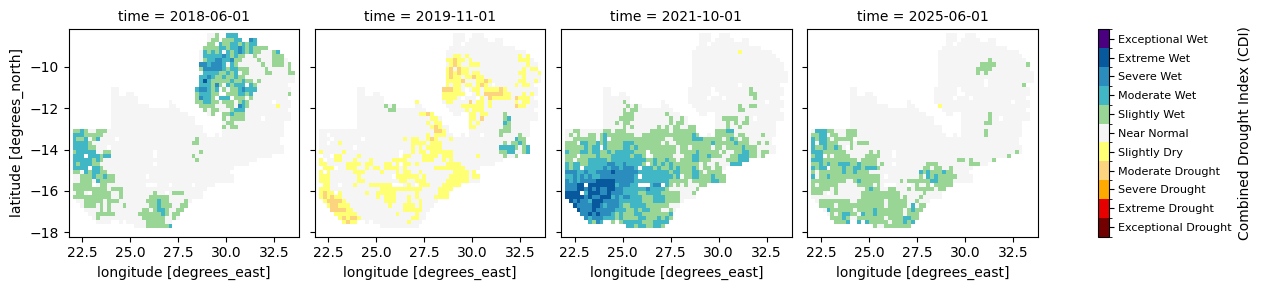

In [81]:
levels = [0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.70, 0.80, 0.90, 0.95, 0.98, 1.0]

# 2. Define text labels corresponding to each of the 11 color blocks
category_labels = [
    "Exceptional Drought",
    "Extreme Drought",
    "Severe Drought",
    "Moderate Drought",
    "Slightly Dry",
    "Near Normal",
    "Slightly Wet",
    "Moderate Wet",
    "Severe Wet",
    "Extreme Wet",
    "Exceptional Wet",
]

# 3. Calculate midpoints of each bin so text sits centered in its color block
midpoints = [(levels[i] + levels[i + 1]) / 2 for i in range(len(levels) - 1)]

# 4. Color palette (Drought -> Normal -> Wet)
cdi_colors = [
    "#730000",  # Exceptional Drought
    "#E60000",  # Extreme Drought
    "#FFAA00",  # Severe Drought
    "#FCD37F",  # Moderate Drought
    "#FFFF73",  # Slightly Dry
    "#F5F5F5",  # Near Normal
    "#99D594",  # Slightly Wet
    "#41B6C4",  # Moderate Wet
    "#2B8CBE",  # Severe Wet
    "#08589E",  # Extreme Wet
    "#4B0082",  # Exceptional Wet
]
cmap_cdi = mcolors.ListedColormap(cdi_colors)

# 5. Plot with word labels
g = ds_percentiles.isel(time=[5, 22, 45, 89]).CDI.plot(
    col="time",
    levels=levels,
    cmap=cmap_cdi,
    cbar_kwargs={
        "label": "Combined Drought Index (CDI)",
        "ticks": midpoints,  # Align ticks to middle of color blocks
        "spacing": "uniform",  # Gives every category equal box height
    },
)

# 6. Apply text labels to colorbar
g.cbar.ax.set_yticklabels(category_labels)
g.cbar.ax.tick_params(labelsize=8)

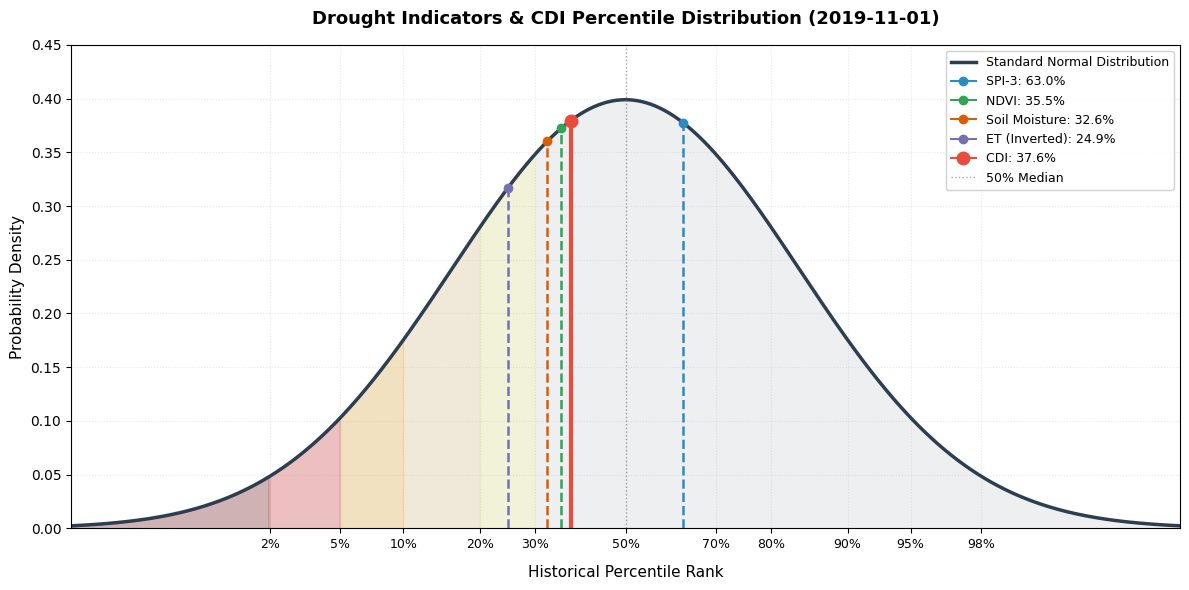

In [82]:
time_target = "2019-11-01"

# Regional Spatial Average across all pixels
ds_sample = ds_percentiles.sel(time=time_target).mean(
    dim=["latitude", "longitude"]
)

percentile_vals = {
    "SPI-3": float(ds_sample["SPI_3"]),
    "NDVI": float(ds_sample["ndvi_mean"]),
    "Soil Moisture": float(ds_sample["soil-moisture"]),
    "ET (Inverted)": float(ds_sample["L1-RET-M"]),
    "CDI": float(ds_sample["CDI"]),
}

# ==========================================
# 2. Build Theoretical Standard Normal Curve
# ==========================================
x = np.linspace(-3.2, 3.2, 1000)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot standard normal bell curve
ax.plot(
    x, y, color="#2c3e50", linewidth=2.5, label="Standard Normal Distribution"
)
ax.fill_between(x, y, color="#2c3e50", alpha=0.08)

# Styling per variable
variable_styles = {
    "SPI-3": {"color": "#2b8cbe", "linestyle": "--", "linewidth": 1.8},
    "NDVI": {"color": "#31a354", "linestyle": "--", "linewidth": 1.8},
    "Soil Moisture": {"color": "#d95f02", "linestyle": "--", "linewidth": 1.8},
    "ET (Inverted)": {"color": "#7570b3", "linestyle": "--", "linewidth": 1.8},
    "CDI": {"color": "#e74c3c", "linestyle": "-", "linewidth": 3.0},
}

# ==========================================
# 3. Map Percentiles & Add Viewer-Friendly Legend
# ==========================================
for var_name, pct in percentile_vals.items():
  pct_clipped = np.clip(pct, 0.0001, 0.9999)
  z_score = stats.norm.ppf(pct_clipped)
  y_height = stats.norm.pdf(z_score)

  style = variable_styles[var_name]
  pct_pct = pct * 100  # Convert to 0–100%

  # Draw vertical drop line
  ax.vlines(
      x=z_score,
      ymin=0,
      ymax=y_height,
      color=style["color"],
      linestyle=style["linestyle"],
      linewidth=style["linewidth"],
  )

  # Mark point with plain-English legend label
  ax.plot(
      z_score,
      y_height,
      marker="o",
      markersize=9 if var_name == "CDI" else 6,
      color=style["color"],
      label=f"{var_name}: {pct_pct:.1f}%",
  )

# ==========================================
# 4. Shade Guillory Category Backgrounds
# ==========================================
category_bounds = [
    (-3.5, stats.norm.ppf(0.02), "#730000", 0.25),  # < 2%
    (stats.norm.ppf(0.02), stats.norm.ppf(0.05), "#E60000", 0.20),  # 2 – 5%
    (stats.norm.ppf(0.05), stats.norm.ppf(0.10), "#FFAA00", 0.20),  # 5 – 10%
    (stats.norm.ppf(0.10), stats.norm.ppf(0.20), "#FCD37F", 0.20),  # 10 – 20%
    (stats.norm.ppf(0.20), stats.norm.ppf(0.30), "#FFFF73", 0.20),  # 20 – 30%
]

for x_start, x_end, col, alp in category_bounds:
  mask = (x >= x_start) & (x <= x_end)
  ax.fill_between(x[mask], y[mask], color=col, alpha=alp)

# ==========================================
# 5. CUSTOM X-AXIS: Map Z-Scores to Percentile %
# ==========================================
# Key percentile ticks matching Guillory categories + median
pct_ticks = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.80, 0.90, 0.95, 0.98]
z_tick_positions = [stats.norm.ppf(p) for p in pct_ticks]
pct_tick_labels = [f"{int(p*100)}%" for p in pct_ticks]

ax.set_xticks(z_tick_positions)
ax.set_xticklabels(pct_tick_labels, fontsize=9)

# Formatting
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(0, 0.45)
ax.set_title(
    f"Drought Indicators & CDI Percentile Distribution ({time_target})",
    fontsize=13,
    pad=15,
    weight="bold",
)
ax.set_xlabel(
    "Historical Percentile Rank",
    fontsize=11,
    labelpad=10,
)
ax.set_ylabel("Probability Density", fontsize=11)

# Highlight median line (50th percentile)
ax.axvline(
    0, color="gray", linestyle=":", linewidth=1, alpha=0.7, label="50% Median"
)

ax.grid(True, linestyle=":", alpha=0.3)
ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=9,
)

plt.tight_layout()
plt.show()

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [ ]:
print(datacube.__version__)

**Last Tested:**

In [ ]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')